# Well-level Pseudobulk Differential Expression and Pathway Analysis

## Objective

Identify the genes and pathways underlying the drug-induced state shifts, using a replicate-aware, count-based approach.

## Experimental design and dose selection

Counts were aggregated at the well level to preserve the highest available experimental replicate structure. The 10 µM dose was selected as a common high dose for Nutlin-3a and vorinostat (sufficient cell numbers and perturbation strength; the highest doses show marked cell loss).

In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "README.md").exists():
    if (PROJECT_ROOT.parent / "README.md").exists():
        PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = PROJECT_ROOT / "figures" / "deg_pathway"
FIG_DIR.mkdir(parents=True, exist_ok=True)
RES_DIR = PROJECT_ROOT / "results" / "task4"
RES_DIR.mkdir(parents=True, exist_ok=True)
sc.settings.set_figure_params(dpi=100, dpi_save=300, frameon=False)
sc.settings.figdir = str(FIG_DIR)

adata = sc.read_h5ad(DATA_DIR / "processed" / "adata_perturbation_landscape.h5ad")
adata


AnnData object with n_obs × n_vars = 23628 × 58347
    obs: 'ncounts', 'hash_umis', 'pval_demultiplexing', 'qval_demultiplexing', 'top_to_second_best_ratio', 'top_oligo', 'perturbation', 'dose_value', 'well', 'celltype', 'cell_line', 'cancer', 'disease', 'tissue_type', 'organism', 'perturbation_type', 'ngenes', 'percent_mito', 'percent_ribo', 'nperts', 'chembl-ID', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'rep_idx', 'is_treated'
    var: 'ensembl_id', 'ncounts', 'ncells', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'dose_value_colors', 'hvg', 'is_treated_colors', 'log1p', 'neighbors', 'pca', 'perturbation_color

In [2]:
cnt = adata.obs.groupby(['perturbation', 'dose_value'], observed=True).size().unstack(fill_value=0)
print("wells per (drug, dose) (replicate):")
print(adata.obs.dropna(subset=['dose_value']).groupby(['perturbation','dose_value'], observed=True)['well'].nunique().iloc[:4].to_string())
print("\ncells table (Nutlin/SAHA/control):")
cnt


wells per (drug, dose) (replicate):
perturbation  dose_value
BMS           0             6
              0.1           6
              0.5           6
              1             6

cells table (Nutlin/SAHA/control):


dose_value,0,0.1,0.5,1,5,10,50,100
perturbation,,,,,,,,
BMS,959,902,703,506,435,292,137,126
Dex,886,897,824,1031,992,882,1115,1257
Nutlin,976,833,768,874,811,1069,395,80
SAHA,983,767,692,639,518,523,717,518


## Well-level pseudobulk

Raw counts were summed within each drug × dose × well to form sample-level profiles; the statistical unit is the well, not the cell.

In [3]:
counts = adata.layers['counts']
obs = adata.obs
dose_list = ['0', '0.1', '0.5', '1', '5', '10', '50', '100']

pb_rows, pb_meta = [], []
for drug in ['Dex', 'Nutlin', 'BMS', 'SAHA']:
    for dose in dose_list:
        m = (obs['perturbation'] == drug) & (obs['dose_value'].astype(str) == dose)
        if m.sum() == 0:
            continue
        for well in sorted(obs.loc[m, 'well'].unique()):
            mw = m & (obs['well'] == well)
            row = np.asarray(counts[mw.values, :].sum(axis=0)).ravel()
            pb_rows.append(row)
            pb_meta.append({'drug': drug, 'dose': float(dose), 'well': well})

pb = pd.DataFrame(np.vstack(pb_rows), columns=adata.var_names)
pb_meta = pd.DataFrame(pb_meta)
pb_meta['sample'] = pb_meta['drug'] + '_' + pb_meta['dose'].astype(str) + '_' + pb_meta['well']
pb.index = pb_meta['sample'].values
pb_meta.index = pb_meta['sample'].values

print("pseudobulk shape (sample × gene):", pb.shape)
print("per-sample library size (total counts): median =", int(pb.sum(axis=1).median()))
pb_meta.head()


pseudobulk shape (sample × gene): (192, 58347)
per-sample library size (total counts): median = 652739


,drug,dose,well,sample
Dex_0.0_AC08,Dex,0.0,AC08,Dex_0.0_AC08
Dex_0.0_AD04,Dex,0.0,AD04,Dex_0.0_AD04
Dex_0.0_AD12,Dex,0.0,AD12,Dex_0.0_AD12
Dex_0.0_BC08,Dex,0.0,BC08,Dex_0.0_BC08
Dex_0.0_BD04,Dex,0.0,BD04,Dex_0.0_BD04


In [4]:
pb_meta.to_csv(RES_DIR / "pseudobulk_metadata.csv")
print("saved pseudobulk_metadata.csv")


saved pseudobulk_metadata.csv


## Differential expression (PyDESeq2)

Count-based negative-binomial models were fit with 6 vs 6 well-level replicates.

In [5]:
from pydeseq2.dds import DeseqDataSet
from pydeseq2.ds import DeseqStats

def run_deg(pb, pb_meta, drug, dose):
    """ drug  dose vs dose=0  pseudobulk DEG, returns results_df"""
    sub_meta = pb_meta[(pb_meta['drug'] == drug) & (pb_meta['dose'].isin([0.0, dose]))].copy()
    sub_counts = pb.loc[sub_meta.index].astype(int)
    sub_meta['condition'] = np.where(sub_meta['dose'] == dose, 'treated', 'control')
    dds = DeseqDataSet(counts=sub_counts, metadata=sub_meta[['condition']],
                       design="~condition", refit_cooks=True, n_cpus=1, quiet=True)
    dds.deseq2()
    st = DeseqStats(dds, contrast=["condition", "treated", "control"], n_cpus=1, quiet=True)
    st.summary()
    return st.results_df

res_nut = run_deg(pb, pb_meta, 'Nutlin', 10.0)
res_saha = run_deg(pb, pb_meta, 'SAHA', 10.0)
print("Nutlin 10µM DEG (padj<0.05):", (res_nut['padj'] < 0.05).sum())
print("SAHA  10µM DEG (padj<0.05):", (res_saha['padj'] < 0.05).sum())


Nutlin 10µM DEG (padj<0.05): 2824
SAHA  10µM DEG (padj<0.05): 7405


In [6]:
def deg_filter(res, padj=0.05, lfc=1.0):
    r = res.dropna(subset=['padj']).copy()
    return r[(r['padj'] < padj) & (r['log2FoldChange'].abs() > lfc)]

nut_sig = deg_filter(res_nut)
saha_sig = deg_filter(res_saha)
print("Nutlin significant & |log2FC|>1:", nut_sig.shape[0])
print("SAHA  significant & |log2FC|>1:", saha_sig.shape[0])


Nutlin significant & |log2FC|>1: 977
SAHA  significant & |log2FC|>1: 4290


## Volcano plots

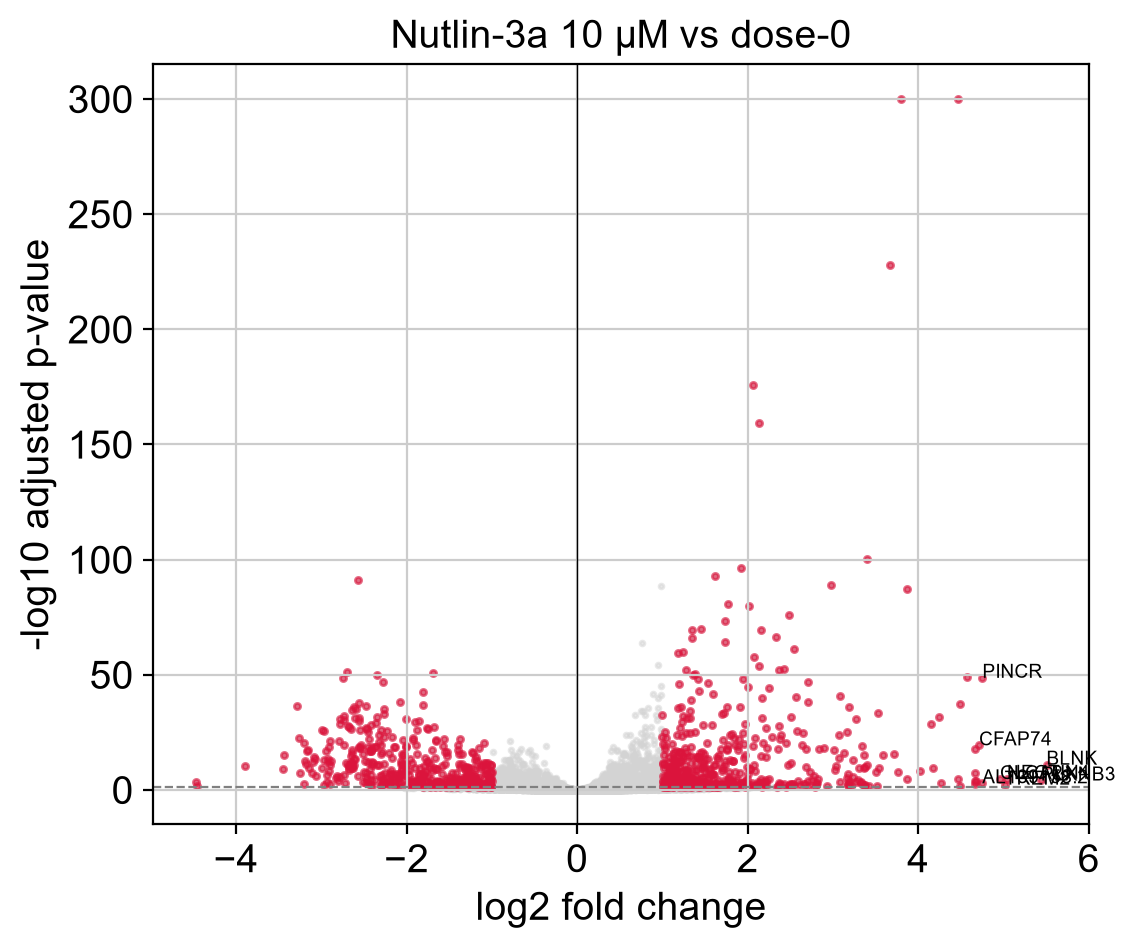

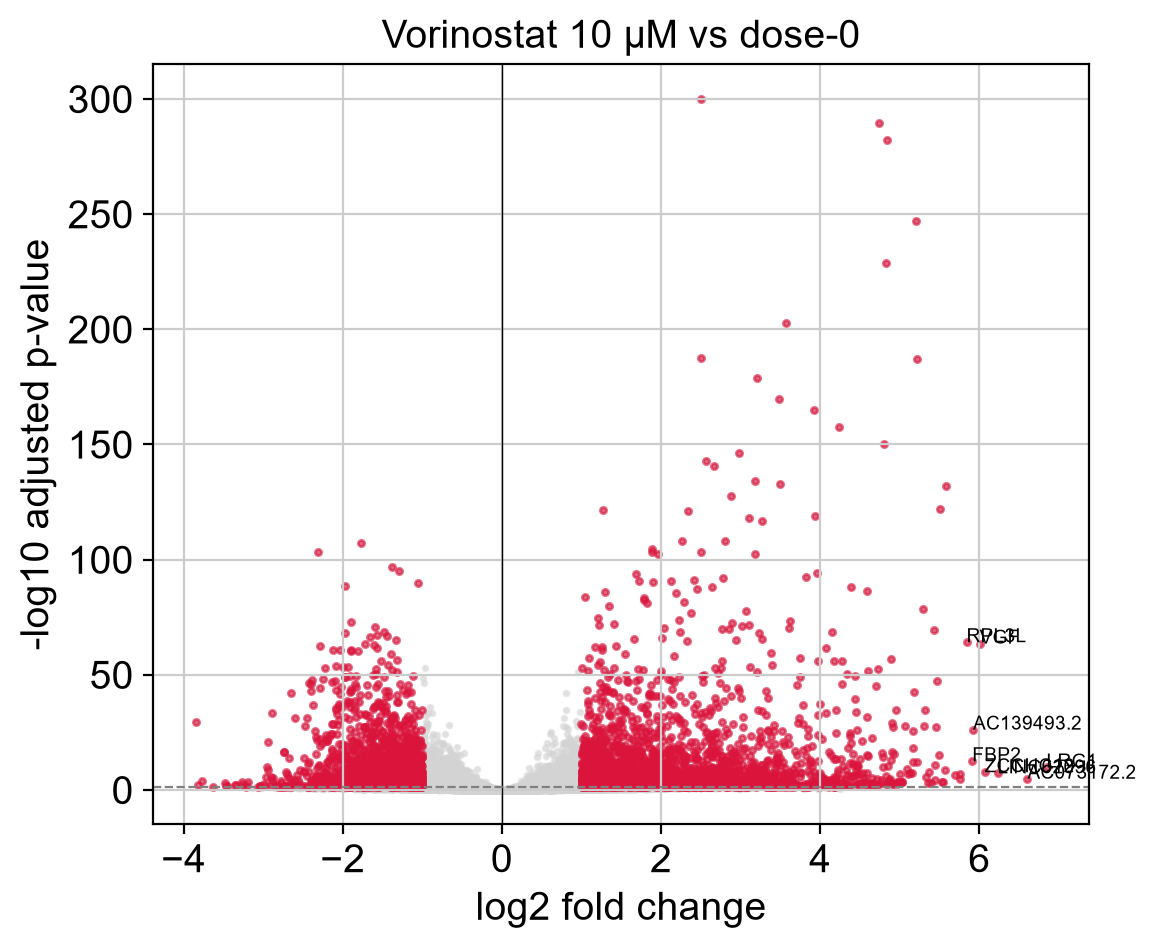

In [7]:
def volcano(res, title, fname, n_label=8):
    r = res.dropna(subset=['padj']).copy()
    r['mlp'] = -np.log10(r['padj'].clip(lower=1e-300))
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(r['log2FoldChange'], r['mlp'], s=3, c='lightgray', alpha=0.5)
    sig = r[(r['padj'] < 0.05) & (r['log2FoldChange'].abs() > 1)]
    ax.scatter(sig['log2FoldChange'], sig['mlp'], s=5, c='crimson', alpha=0.6)
    ax.axvline(0, color='k', lw=0.5)
    ax.axhline(-np.log10(0.05), color='gray', ls='--', lw=0.8)
    top = sig.reindex(sig['log2FoldChange'].abs().sort_values(ascending=False).index).head(n_label)
    for g, row in top.iterrows():
        ax.annotate(g, (row['log2FoldChange'], row['mlp']), fontsize=7)
    ax.set_xlabel('log2 fold change'); ax.set_ylabel('-log10 adjusted p-value')
    ax.set_title(title)
    fig.savefig(FIG_DIR / fname, dpi=300, bbox_inches='tight')
    plt.show()

volcano(res_nut, 'Nutlin-3a 10 µM vs dose-0', 'task4_nutlin_volcano.png')
volcano(res_saha, 'Vorinostat 10 µM vs dose-0', 'task4_vorinostat_volcano.png')


In [8]:
def top_deg_table(res, n=10):
    r = deg_filter(res)
    up = r[r['log2FoldChange'] > 0].sort_values('log2FoldChange', ascending=False).head(n)
    dn = r[r['log2FoldChange'] < 0].sort_values('log2FoldChange').head(n)
    return pd.concat([up, dn])[['log2FoldChange', 'padj']]

print("=== Nutlin Top DEG (up/down) ===")
top_deg_table(res_nut)


=== Nutlin Top DEG (up/down) ===


,log2FoldChange,padj
gene_symbol,,
BLNK,5.505137,1.122892e-11
PLXNB3,5.438273,8.174354e-05
NECTIN4,5.041888,1.549143e-05
TREM2,5.013909,5.077743e-03
CLCA2,4.959892,2.156004e-05
PINCR,4.753848,2.176765e-49
AL139158.2,4.751545,1.324906e-03
CFAP74,4.714547,4.548481e-20
CYGB,4.679333,9.006097e-05


In [9]:
res_nut.to_csv(RES_DIR / "nutlin_deg.csv")
res_saha.to_csv(RES_DIR / "vorinostat_deg.csv")
print("saved nutlin_deg.csv / vorinostat_deg.csv")


saved nutlin_deg.csv / vorinostat_deg.csv


## Dose-dependent gene trajectories

Response genes were examined across doses; trajectories are dose-dependent and potentially nonlinear.

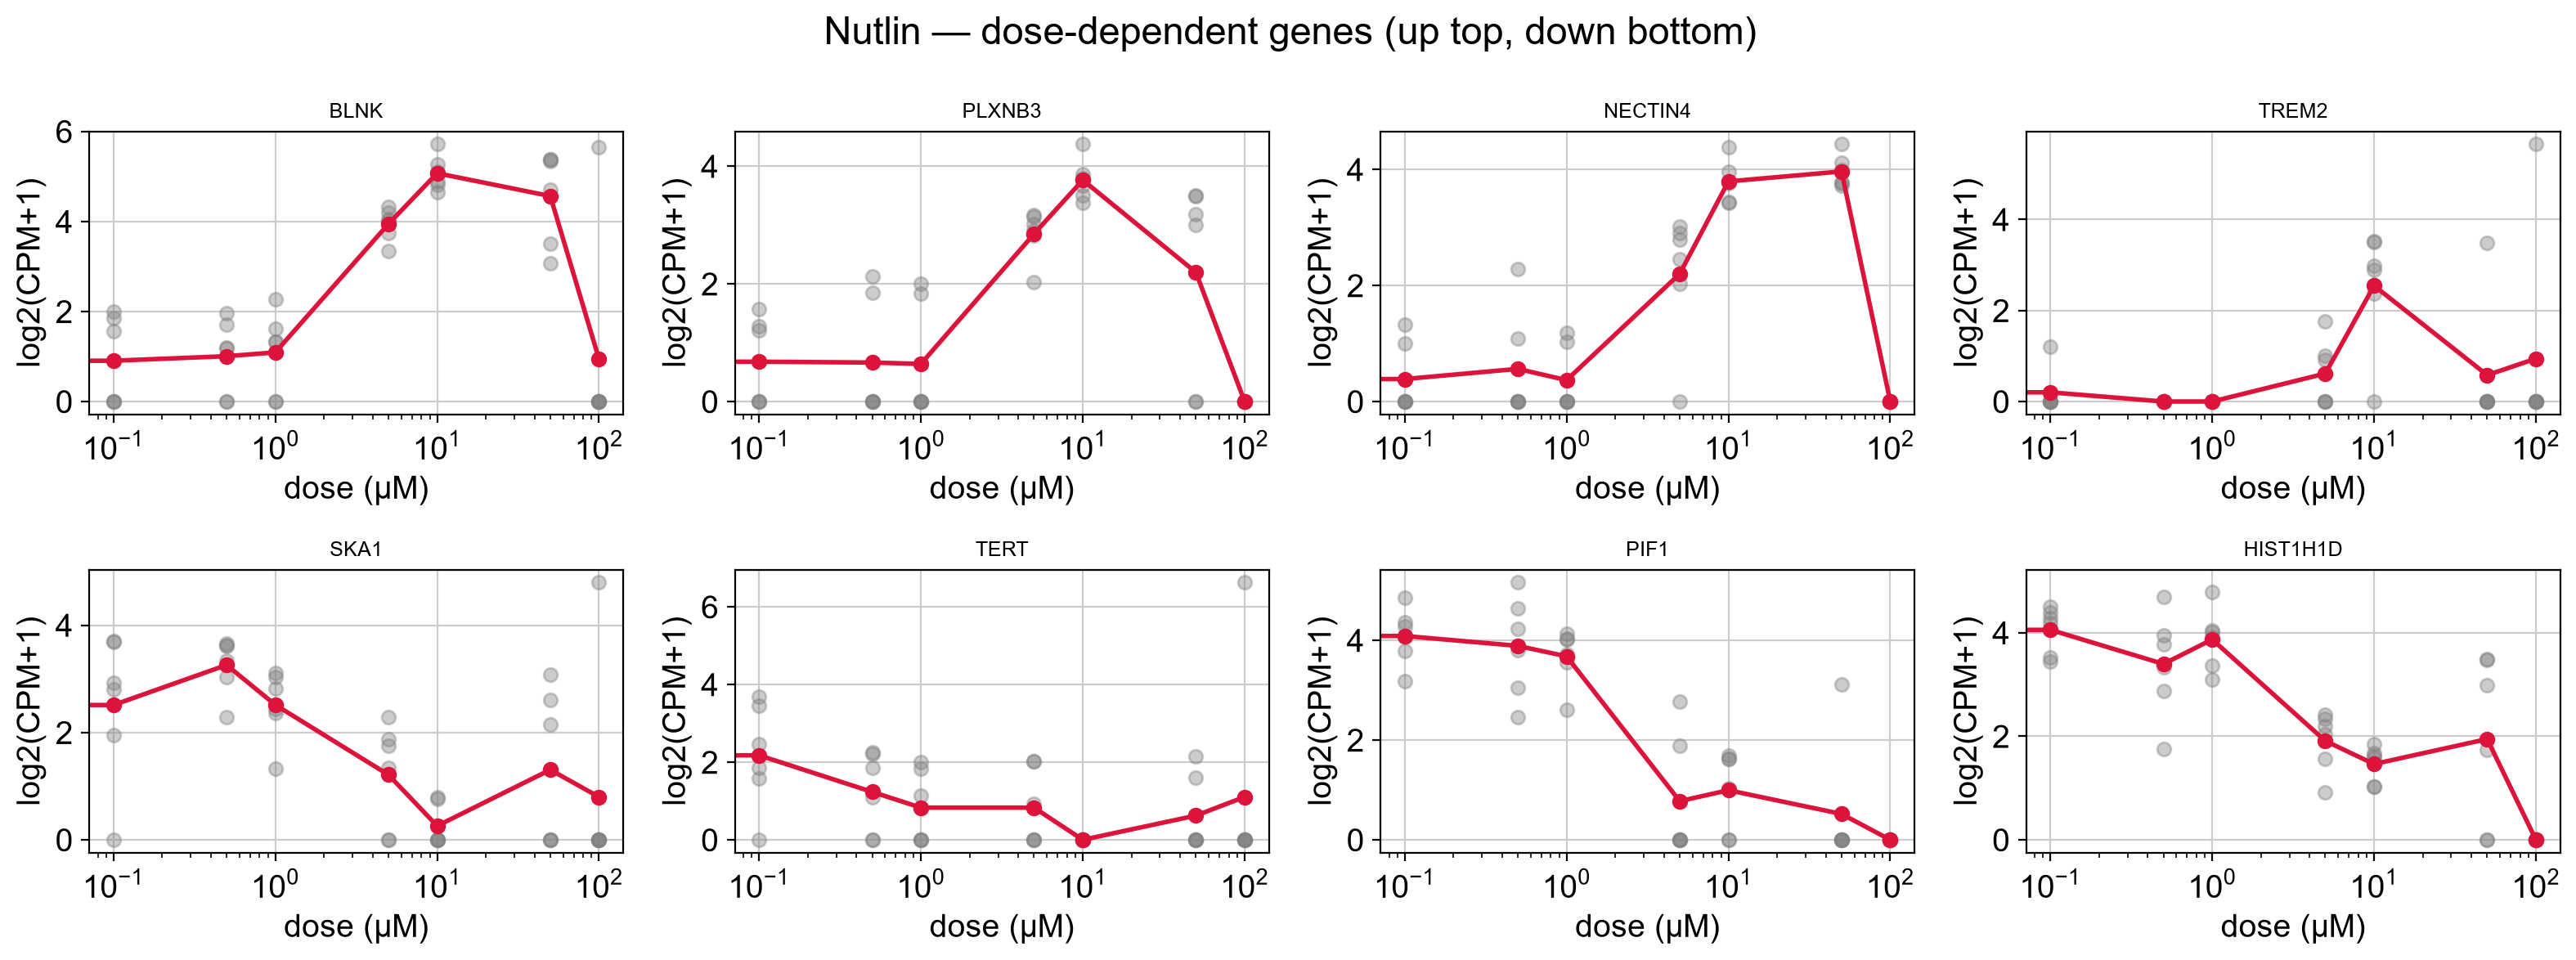

In [10]:
def gene_trajectory(pb, pb_meta, drug, gene):
    sub = pb_meta[pb_meta['drug'] == drug]
    sub_counts = pb.loc[sub.index]
    cpm = sub_counts.div(sub_counts.sum(axis=1), axis=0) * 1e6
    expr = np.log2(cpm[gene] + 1)
    return pd.DataFrame({'dose': sub['dose'].values, 'expr': expr.values, 'well': sub['well'].values})

def plot_dose_genes(pb, pb_meta, drug, res, fname):
    r = deg_filter(res)
    up = r[r['log2FoldChange'] > 0].sort_values('log2FoldChange', ascending=False).head(4).index
    dn = r[r['log2FoldChange'] < 0].sort_values('log2FoldChange').head(4).index
    genes = list(up) + list(dn)
    fig, axes = plt.subplots(2, 4, figsize=(16, 6))
    for ax, g in zip(axes.ravel(), genes):
        df = gene_trajectory(pb, pb_meta, drug, g)
        for w, gg in df.groupby('well'):
            gg = gg.sort_values('dose')
            ax.plot(gg['dose'], gg['expr'], 'o-', lw=1, alpha=0.4, color='gray')
        mean = df.groupby('dose')['expr'].mean()
        ax.plot(mean.index, mean.values, 'o-', color='crimson', lw=2)
        ax.set_xscale('log'); ax.set_title(g, fontsize=9); ax.set_xlabel('dose (µM)'); ax.set_ylabel('log2(CPM+1)')
    fig.suptitle(f'{drug} — dose-dependent genes (up top, down bottom)')
    fig.tight_layout()
    fig.savefig(FIG_DIR / fname, dpi=300, bbox_inches='tight')
    plt.show()

plot_dose_genes(pb, pb_meta, 'Nutlin', res_nut, 'task4_dose_gene_trajectories.png')


## Hallmark pathway enrichment

Significant up- and down-regulated genes were tested against MSigDB Hallmark gene sets.

In [11]:
import gseapy as gp

def enrich(gene_list, n_top=15):
    if len(gene_list) == 0:
        return pd.DataFrame()
    enr = gp.enrichr(gene_list=list(gene_list), gene_sets='MSigDB_Hallmark_2020',
                     outdir=None, no_plot=True)
    return enr.results.head(n_top)

def sig_genes(res, direction='up'):
    r = deg_filter(res)
    r = r[r['log2FoldChange'] > 0] if direction == 'up' else r[r['log2FoldChange'] < 0]
    return r.index.tolist()

nut_up = enrich(sig_genes(res_nut, 'up'))
nut_dn = enrich(sig_genes(res_nut, 'down'))
saha_up = enrich(sig_genes(res_saha, 'up'))
saha_dn = enrich(sig_genes(res_saha, 'down'))
print("=== Nutlin UP pathways ===")
nut_up[['Term', 'Adjusted P-value']].head(8)


=== Nutlin UP pathways ===


,Term,Adjusted P-value
0,p53 Pathway,1.250928e-46
1,Epithelial Mesenchymal Transition,1.670748e-03
2,Inflammatory Response,1.670748e-03
3,TNF-alpha Signaling via NF-kB,4.066015e-03
4,Apoptosis,1.276805e-02
5,Apical Junction,6.085576e-02
6,Cholesterol Homeostasis,9.134003e-02
7,Estrogen Response Early,1.105570e-01


In [12]:
print("=== Nutlin DOWN pathways ===")
nut_dn[['Term', 'Adjusted P-value']].head(8)


=== Nutlin DOWN pathways ===


,Term,Adjusted P-value
0,E2F Targets,8.828976e-99
1,G2-M Checkpoint,1.000634e-82
2,Mitotic Spindle,4.135695e-26
3,Spermatogenesis,1.312701e-05
4,DNA Repair,1.765871e-04
5,Myc Targets V2,1.499208e-03
6,Estrogen Response Late,2.009676e-03
7,Myc Targets V1,2.009676e-03


In [13]:
print("=== SAHA UP pathways ===")
saha_up[['Term', 'Adjusted P-value']].head(8)


=== SAHA UP pathways ===


,Term,Adjusted P-value
0,Cholesterol Homeostasis,0.000003
1,UV Response Up,0.000005
2,TNF-alpha Signaling via NF-kB,0.001247
3,Apoptosis,0.002162
4,p53 Pathway,0.005901
5,mTORC1 Signaling,0.087851
6,Hypoxia,0.107569
7,heme Metabolism,0.107569


In [14]:
nut_up.assign(direction='up').to_csv(RES_DIR / "nutlin_pathways.csv", index=False)
nut_dn.assign(direction='down').to_csv(RES_DIR / "nutlin_pathways.csv", mode='a', index=False, header=False)
saha_up.assign(direction='up').to_csv(RES_DIR / "vorinostat_pathways.csv", index=False)
saha_dn.assign(direction='down').to_csv(RES_DIR / "vorinostat_pathways.csv", mode='a', index=False, header=False)
print("saved pathway tables")


saved pathway tables


## Pathway comparison

A diverging bar chart contrasts the two drugs' Hallmark responses (positive = upregulated, negative = downregulated).

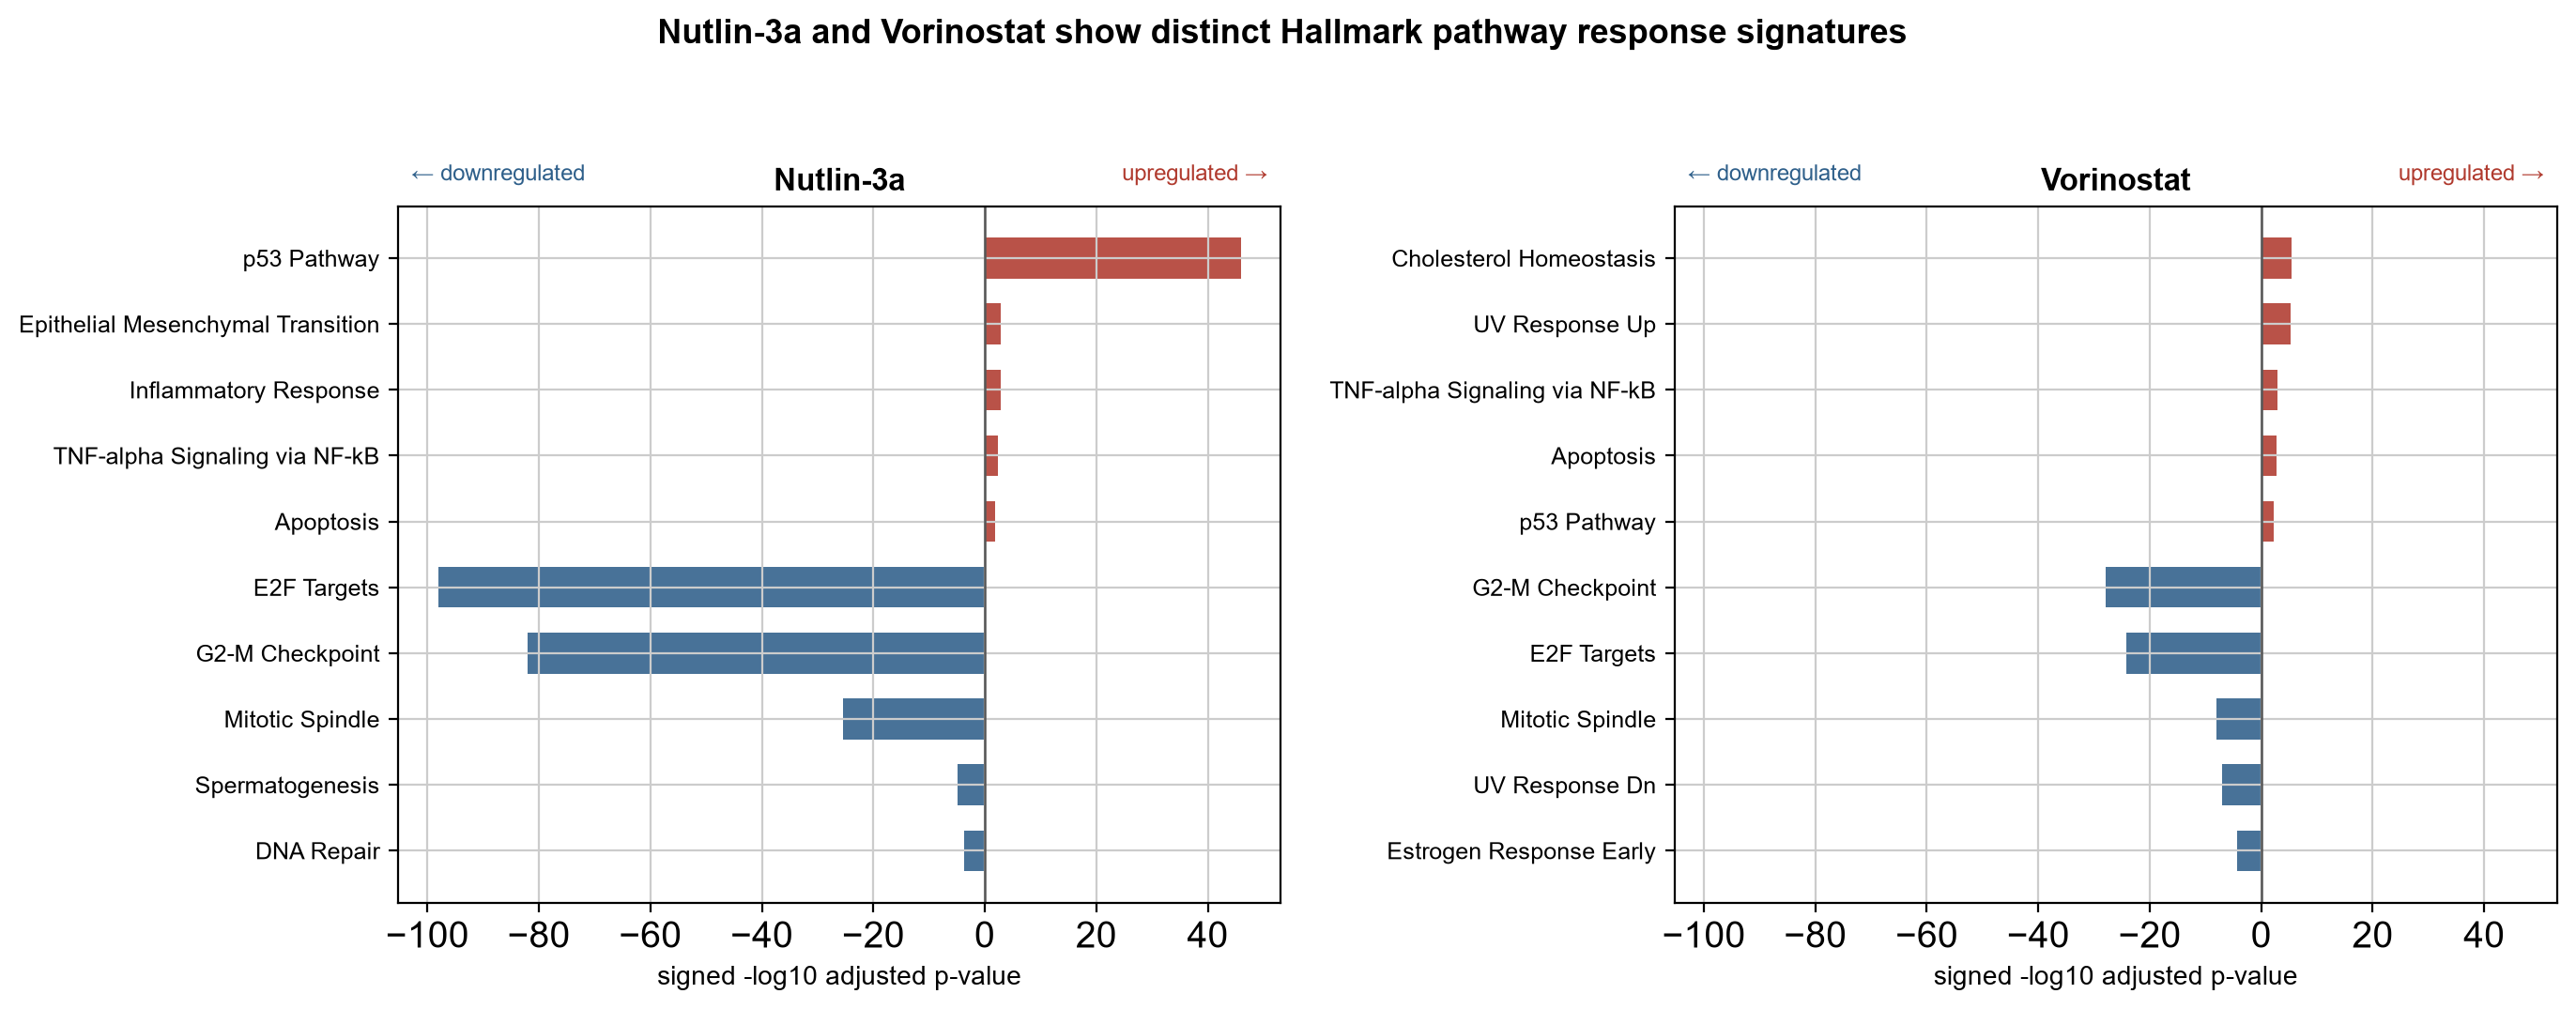

In [15]:
UP_COLOR = '#B03A2E'
DN_COLOR = '#2E5F8A'

def diverging_pathways(up_df, dn_df, n=5):
    up = up_df.head(n).sort_values('Adjusted P-value')
    dn = dn_df.head(n).sort_values('Adjusted P-value')
    up_l = [(r['Term'], -np.log10(r['Adjusted P-value'])) for _, r in up.iterrows()]
    dn_l = [(r['Term'], -(-np.log10(r['Adjusted P-value']))) for _, r in dn.iterrows()]
    return up_l, dn_l

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharex=True)
for ax, (title, up_df, dn_df) in zip(axes, [
    ('Nutlin-3a', nut_up, nut_dn),
    ('Vorinostat', saha_up, saha_dn),
]):
    up_l, dn_l = diverging_pathways(up_df, dn_df)
    terms = [t for t, _ in up_l] + [t for t, _ in dn_l]
    vals  = [v for _, v in up_l] + [v for _, v in dn_l]
    colors = [UP_COLOR] * len(up_l) + [DN_COLOR] * len(dn_l)
    y = np.arange(len(terms))[::-1]
    ax.barh(y, vals, color=colors, alpha=0.88, height=0.62)
    ax.set_yticks(y); ax.set_yticklabels(terms, fontsize=9)
    ax.axvline(0, color='#555555', lw=0.9)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlabel('signed -log10 adjusted p-value', fontsize=10)
    ax.text(0.985, 1.03, 'upregulated →', transform=ax.transAxes, ha='right', va='bottom', color=UP_COLOR, fontsize=8.5)
    ax.text(0.015, 1.03, '← downregulated', transform=ax.transAxes, ha='left', va='bottom', color=DN_COLOR, fontsize=8.5)
fig.suptitle('Nutlin-3a and Vorinostat show distinct Hallmark pathway response signatures', fontweight='bold', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.95])
fig.savefig(FIG_DIR / 'task4_pathway_comparison.png', dpi=300, bbox_inches='tight')
plt.show()


## DEG overlap (shared vs drug-specific)

up shared: 130 | Nutlinspecificup: 413 | SAHAspecificup: 2479
down shared: 202 | Nutlinspecificdown: 232 | SAHAspecificdown: 1479


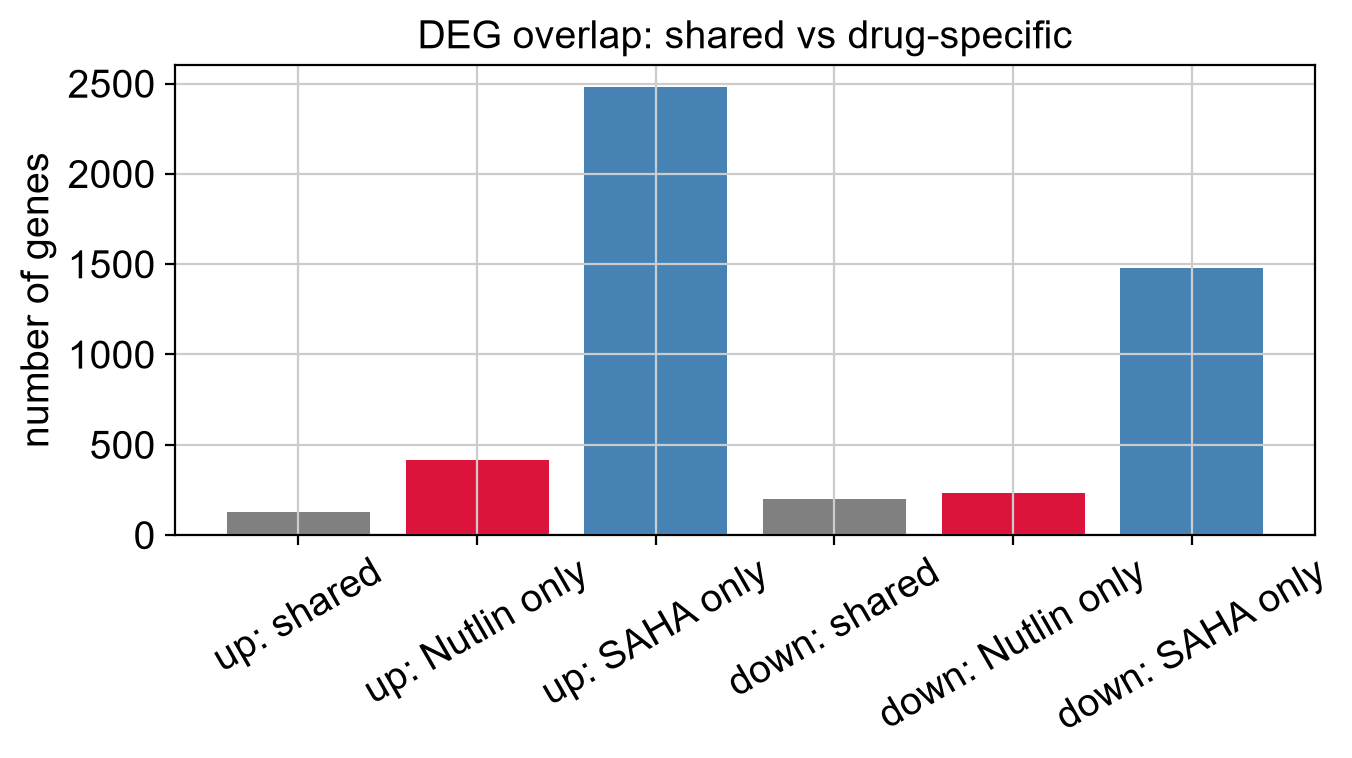

In [16]:
nut_up_set = set(sig_genes(res_nut, 'up')); nut_dn_set = set(sig_genes(res_nut, 'down'))
saha_up_set = set(sig_genes(res_saha, 'up')); saha_dn_set = set(sig_genes(res_saha, 'down'))

shared_up = nut_up_set & saha_up_set
shared_dn = nut_dn_set & saha_dn_set
print(f"up shared: {len(shared_up)} | Nutlinspecificup: {len(nut_up_set - saha_up_set)} | SAHAspecificup: {len(saha_up_set - nut_up_set)}")
print(f"down shared: {len(shared_dn)} | Nutlinspecificdown: {len(nut_dn_set - saha_dn_set)} | SAHAspecificdown: {len(saha_dn_set - nut_dn_set)}")

cats = ['up: shared', 'up: Nutlin only', 'up: SAHA only', 'down: shared', 'down: Nutlin only', 'down: SAHA only']
vals = [len(shared_up), len(nut_up_set - saha_up_set), len(saha_up_set - nut_up_set),
        len(shared_dn), len(nut_dn_set - saha_dn_set), len(saha_dn_set - nut_dn_set)]
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(cats, vals, color=['gray', 'crimson', 'steelblue', 'gray', 'crimson', 'steelblue'])
ax.set_ylabel('number of genes')
ax.tick_params(axis='x', rotation=30)
ax.set_title('DEG overlap: shared vs drug-specific')
fig.tight_layout()
fig.savefig(FIG_DIR / 'task4_deg_overlap.png', dpi=300, bbox_inches='tight')
plt.show()


## Replicate consistency

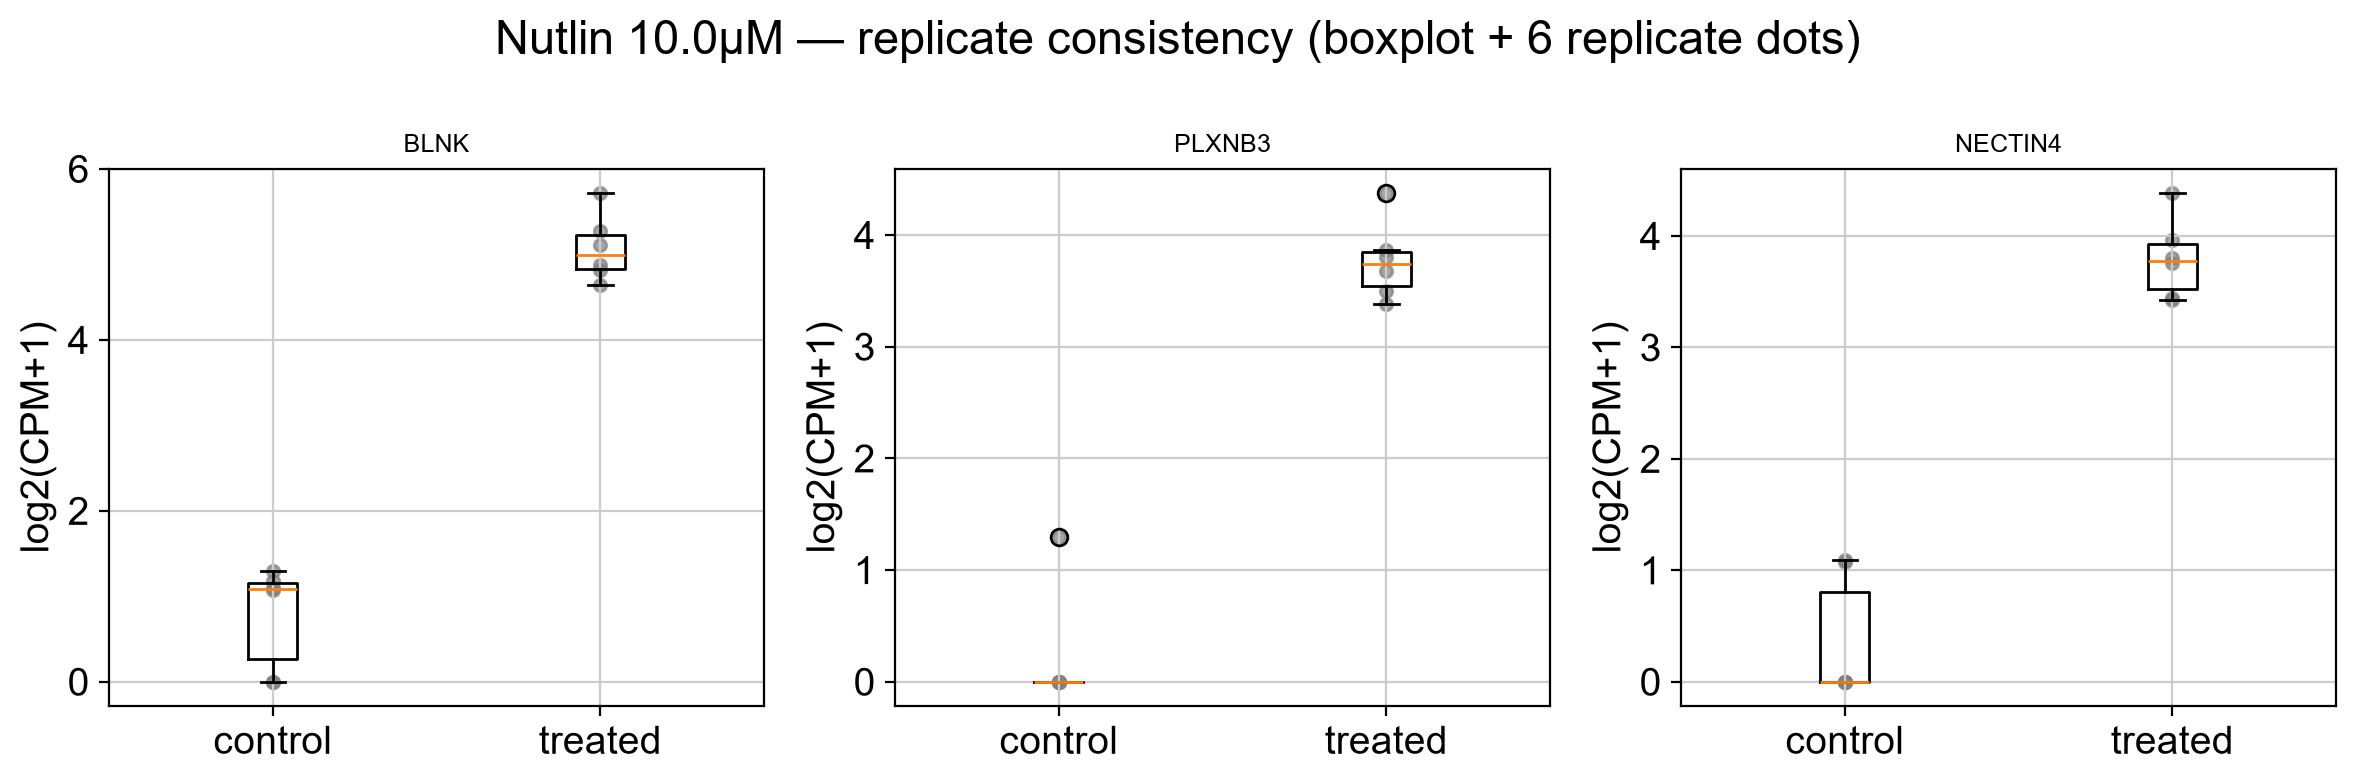

In [17]:
def replicate_consistency(pb, pb_meta, drug, dose, genes):
    sub = pb_meta[(pb_meta['drug'] == drug) & (pb_meta['dose'].isin([0.0, dose]))]
    sub_counts = pb.loc[sub.index]
    cpm = sub_counts.div(sub_counts.sum(axis=1), axis=0) * 1e6
    fig, axes = plt.subplots(1, len(genes), figsize=(4*len(genes), 4))
    if len(genes) == 1:
        axes = [axes]
    for ax, g in zip(axes, genes):
        df = pd.DataFrame({'cond': np.where(sub['dose'].values == dose, 'treated', 'control'),
                           'expr': np.log2(cpm[g] + 1).values})
        data = [df[df['cond'] == 'control']['expr'].values, df[df['cond'] == 'treated']['expr'].values]
        ax.boxplot(data, tick_labels=['control', 'treated'])
        for i, d in enumerate(data):
            ax.scatter([i+1]*len(d), d, color='gray', s=20, alpha=0.7)
        ax.set_title(g, fontsize=9); ax.set_ylabel('log2(CPM+1)')
    fig.suptitle(f'{drug} {dose}µM — replicate consistency (boxplot + 6 replicate dots)')
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'task4_replicate_consistency.png', dpi=300, bbox_inches='tight')
    plt.show()

nut_top3 = deg_filter(res_nut).sort_values('log2FoldChange', ascending=False).head(3).index.tolist()
saha_top3 = deg_filter(res_saha).sort_values('log2FoldChange', ascending=False).head(3).index.tolist()
replicate_consistency(pb, pb_meta, 'Nutlin', 10.0, nut_top3)


## Summary

| Metric | Nutlin-3a | Vorinostat / SAHA |
|---|---:|---:|
| DEGs (FDR < 0.05) | 2,824 | 7,405 |
| Significant & \|log2FC\| > 1 | 977 | 4,290 |
| Dominant upregulated program | p53 pathway (adjusted p ≈ 1.3e-46) | cholesterol / UV-response / TNF-related programs |
| Strong downregulated programs | E2F Targets, G2M Checkpoint, Mitotic Spindle | E2F Targets, G2M Checkpoint, Mitotic Spindle |
| Shared upregulated genes | 130 | 130 |
| Drug-specific upregulated genes | 413 | 2,479 |

**Nutlin-3a** induces a dominant p53-associated transcriptional program together with strong downregulation of cell-cycle pathways, consistent with inhibition of MDM2-mediated p53 degradation. **Vorinostat** induces a broader transcriptional response, consistent with the widespread regulatory effects of HDAC inhibition, with pathway enrichment that is weaker and less target-specific than the Nutlin-3a response. The directional divergence observed in Task 3 is interpreted in light of these drug-specific programs; these associations support, but do not causally establish, distinct pharmacological mechanisms.

These findings motivate the held-out prediction analysis in Task 5.